# Top Trumps Balancing - Optimierung

## Multi-Objective Optimization mit NSGA-II

Dieses Notebook führt die eigentliche Optimierung durch:
1. Pymoo Problem-Wrapper Definition
2. NSGA-II Algorithmus Konfiguration
3. Optimierungslauf (FAST mit R=100)
4. Validierung (FINAL mit R=1000)

---

## 1. Setup & Konfiguration laden

In [1]:
%pip install numpy pymoo pandas matplotlib seaborn tqdm --quiet


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from tqdm import tqdm

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.termination import get_termination

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [3]:
RESULTS_DIR = Path("results")
PLOTS_DIR = Path("plots")

config_path = RESULTS_DIR / 'config.json'
with open(config_path, 'r') as f:
    CONFIG = json.load(f)

SEED = CONFIG['seed']
K = CONFIG['K']
L = CONFIG['L']
XL = CONFIG['xl']
XU = CONFIG['xu']
R_EVAL_FAST = CONFIG['R_eval_fast']
R_EVAL_FINAL = CONFIG['R_eval_final']

def set_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)

set_seeds(SEED)

print("Konfiguration geladen:")
print(json.dumps(CONFIG, indent=2))

Konfiguration geladen:
{
  "seed": 42,
  "K": 22,
  "L": 4,
  "n_var": 88,
  "xl": 1.0,
  "xu": 10.0,
  "R_eval_fast": 500,
  "R_eval_final": 1000,
  "exploration_stats": {
    "win_rate_range": [
      0.42,
      0.69
    ],
    "trick_changes_range": [
      1.33,
      2.66
    ]
  }
}


---

## 2. Simulation Engine (aus Notebook 1)

In [4]:
from simulation import TopTrumpsSimulation, TopTrumpsBalancing


sim = TopTrumpsSimulation(num_cards=K, num_categories=L)
print(f"Simulation erstellt: {K} Karten, {L} Kategorien")

Simulation erstellt: 22 Karten, 4 Kategorien


---

## 3. Pymoo Problem-Wrapper (TopTrumpsBalancing)

Pymoo minimiert standardmäßig, daher werden die Objectives negiert:
- f1 = -win_rate (maximiere Win Rate)
- f2 = -trick_changes (maximiere Trick Changes)

---

## 4. Algorithmus-Konfiguration

### NSGA-II Parameter

- **Population Size:** 100 (erhöht für mehr Diversität)
- **Generationen:** 100 (erhöht für bessere Konvergenz)
- **Crossover:** SBX (Simulated Binary Crossover) mit eta=15
- **Mutation:** Polynomial Mutation mit eta=20

### Budget-Kalkulation (FAST Run):
- Evaluierungen: pop_size × n_gen = 100 × 100 = 10.000
- Simulationen pro Evaluation: R_eval_fast = 200
- Gesamte Simulationen: **2.000.000** (~4x mehr als vorher)

In [5]:
POP_SIZE = 100
N_GEN = 200
R_EVAL_FAST = 500

ALGO_CONFIG = {
    "pop_size": POP_SIZE,
    "n_gen": N_GEN,
    "crossover_eta": 15,
    "mutation_eta": 20,
    "R_simulations": R_EVAL_FAST
}

print("Algorithmus-Konfiguration:")
print(json.dumps(ALGO_CONFIG, indent=2))
print(f"\nGeschätztes Budget: {POP_SIZE * N_GEN * R_EVAL_FAST:,} Simulationen")

Algorithmus-Konfiguration:
{
  "pop_size": 100,
  "n_gen": 200,
  "crossover_eta": 15,
  "mutation_eta": 20,
  "R_simulations": 500
}

Geschätztes Budget: 10,000,000 Simulationen


---

## 5. Optimierungslauf (FAST mit R=100)

In [6]:
set_seeds(SEED)

problem = TopTrumpsBalancing(sim, n_simulations=R_EVAL_FAST, xl=XL, xu=XU)

algorithm = NSGA2(
    pop_size=POP_SIZE,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=ALGO_CONFIG["crossover_eta"]),
    mutation=PM(eta=ALGO_CONFIG["mutation_eta"]),
    eliminate_duplicates=True
)

termination = get_termination("n_gen", N_GEN)

print(f"Starte NSGA-II Optimierung...")
print(f"  Population: {POP_SIZE}")
print(f"  Generationen: {N_GEN}")
print(f"  Simulationen pro Evaluation: {R_EVAL_FAST}")
print(f"  Erwartete Laufzeit: ~{POP_SIZE * N_GEN * R_EVAL_FAST / 1000:.0f}k Simulationen")

Starte NSGA-II Optimierung...
  Population: 100
  Generationen: 200
  Simulationen pro Evaluation: 500
  Erwartete Laufzeit: ~10000k Simulationen


In [7]:
start_time = time.time()

result = minimize(
    problem,
    algorithm,
    termination,
    seed=SEED,
    verbose=True,
    save_history=True
)

elapsed_time = time.time() - start_time

print(f"\n=== Optimierung abgeschlossen ===")
print(f"Laufzeit: {elapsed_time:.1f} Sekunden ({elapsed_time/60:.1f} Minuten)")
print(f"Gefundene nicht-dominierte Lösungen: {len(result.F)}")

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      3 |             - |             -


     2 |      200 |      7 |  0.1720779221 |         ideal


     3 |      300 |     10 |  0.3389830508 |         ideal


     4 |      400 |      5 |  0.1549019608 |         ideal


     5 |      500 |      5 |  0.0162532135 |             f


...

   196 |    19600 |     22 |  0.0014084828 |             f


   197 |    19700 |     22 |  0.0014084828 |             f


   198 |    19800 |     22 |  0.0014084828 |             f


   199 |    19900 |     22 |  0.0014084828 |             f


   200 |    20000 |     22 |  0.0014084828 |             f

=== Optimierung abgeschlossen ===
Laufzeit: 234.2 Sekunden (3.9 Minuten)
Gefundene nicht-dominierte Lösungen: 22


In [8]:
fast_front_X = result.X
fast_front_F = result.F

fast_win_rates = -fast_front_F[:, 0]
fast_trick_changes = -fast_front_F[:, 1]

print(f"\n=== FAST Front Statistiken (R={R_EVAL_FAST}) ===")
print(f"Win Rate:       Min={fast_win_rates.min():.1%}, Max={fast_win_rates.max():.1%}")
print(f"Trick Changes:  Min={fast_trick_changes.min():.2f}, Max={fast_trick_changes.max():.2f}")


=== FAST Front Statistiken (R=500) ===
Win Rate:       Min=69.8%, Max=91.2%
Trick Changes:  Min=3.05, Max=4.68


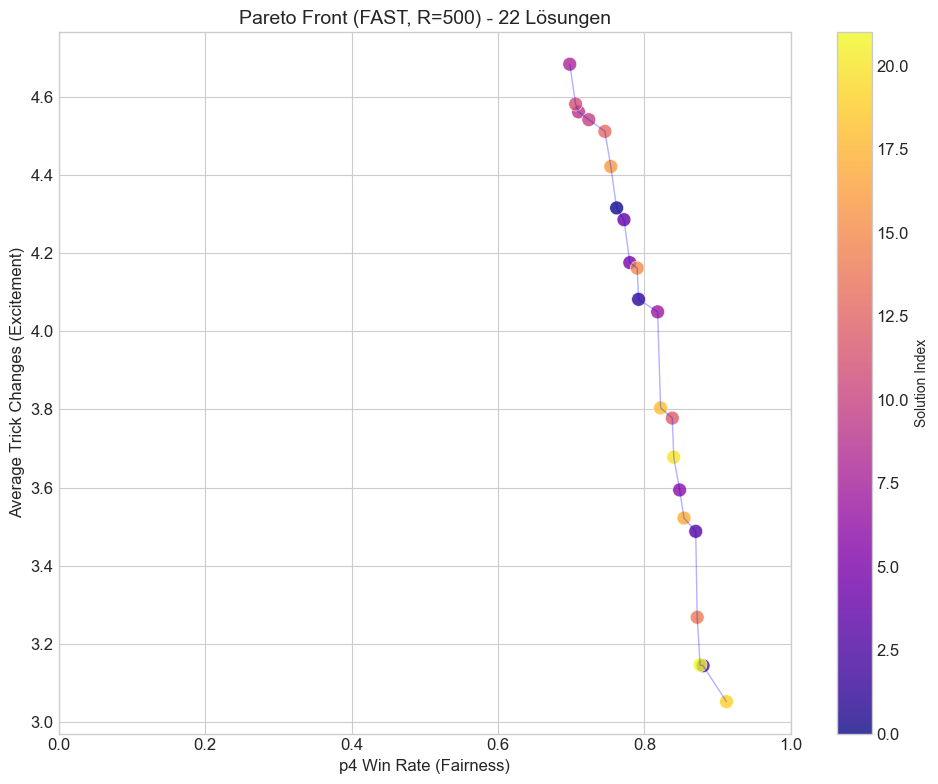


-> Plot gespeichert: plots/pareto_front_fast.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

sorted_idx = np.argsort(fast_win_rates)
ax.plot(fast_win_rates[sorted_idx], fast_trick_changes[sorted_idx], 'b-', alpha=0.3, linewidth=1)

scatter = ax.scatter(
    fast_win_rates,
    fast_trick_changes,
    c=np.arange(len(fast_win_rates)),
    cmap='plasma',
    s=100,
    alpha=0.8,
    edgecolors='white',
    linewidth=0.5
)

ax.set_xlabel('p4 Win Rate (Fairness)', fontsize=12)
ax.set_ylabel('Average Trick Changes (Excitement)', fontsize=12)
ax.set_title(f'Pareto Front (FAST, R={R_EVAL_FAST}) - {len(fast_win_rates)} Lösungen', fontsize=14)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Solution Index', fontsize=10)

ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pareto_front_fast.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n-> Plot gespeichert: {PLOTS_DIR / 'pareto_front_fast.png'}")

---

## 6. Validierung (FINAL mit R=1000)

Die gefundenen Lösungen werden mit R=1000 Simulationen re-evaluiert, um robustere Schätzungen zu erhalten.

In [10]:
def evaluate_deck_detailed(sim, deck, R):
    sim.set_deck(deck)
    
    win_rates = []
    trick_changes_list = []
    p4_tricks_list = []
    
    for _ in range(R):
        result = sim.simulate_game()
        win_rates.append(1 if result['p4_won'] else 0)
        trick_changes_list.append(result['trick_changes'])
        p4_tricks_list.append(result['p4_tricks'])
    
    return {
        "win_rate": np.mean(win_rates),
        "win_rate_std": np.std(win_rates),
        "win_rate_ci": 1.96 * np.std(win_rates) / np.sqrt(R),
        "trick_changes": np.mean(trick_changes_list),
        "trick_changes_std": np.std(trick_changes_list),
        "trick_changes_ci": 1.96 * np.std(trick_changes_list) / np.sqrt(R),
        "p4_tricks_mean": np.mean(p4_tricks_list)
    }

In [11]:
print(f"Starte Validierung mit R={R_EVAL_FINAL}...")
print(f"Anzahl Lösungen: {len(fast_front_X)}")

validated_results = []
start_time = time.time()

for i, deck in enumerate(tqdm(fast_front_X, desc="Validierung")):
    metrics = evaluate_deck_detailed(sim, deck, R_EVAL_FINAL)
    validated_results.append({
        "solution_id": i,
        "win_rate": metrics["win_rate"],
        "win_rate_std": metrics["win_rate_std"],
        "win_rate_ci": metrics["win_rate_ci"],
        "trick_changes": metrics["trick_changes"],
        "trick_changes_std": metrics["trick_changes_std"],
        "trick_changes_ci": metrics["trick_changes_ci"],
        "p4_tricks_mean": metrics["p4_tricks_mean"]
    })

validation_time = time.time() - start_time

validated_df = pd.DataFrame(validated_results)
print(f"\nValidierung abgeschlossen in {validation_time:.1f} Sekunden ({validation_time/60:.1f} Minuten)")

Starte Validierung mit R=1000...
Anzahl Lösungen: 22


Validierung:   0%|          | 0/22 [00:00<?, ?it/s]

Validierung:  23%|██▎       | 5/22 [00:00<00:00, 42.16it/s]

Validierung:  45%|████▌     | 10/22 [00:00<00:00, 41.35it/s]

Validierung:  68%|██████▊   | 15/22 [00:00<00:00, 41.44it/s]

Validierung:  91%|█████████ | 20/22 [00:00<00:00, 36.00it/s]

Validierung: 100%|██████████| 22/22 [00:00<00:00, 38.02it/s]


Validierung abgeschlossen in 0.6 Sekunden (0.0 Minuten)


In [12]:
print("\n=== Validated Front Statistiken (R=1000) ===")
print(f"Win Rate:       Min={validated_df['win_rate'].min():.1%}, Max={validated_df['win_rate'].max():.1%}")
print(f"Trick Changes:  Min={validated_df['trick_changes'].min():.2f}, Max={validated_df['trick_changes'].max():.2f}")

print("\n=== Vergleich FAST vs VALIDATED ===")
print(f"Win Rate  - FAST Mean: {fast_win_rates.mean():.1%}, VALIDATED Mean: {validated_df['win_rate'].mean():.1%}")
print(f"Trick Ch. - FAST Mean: {fast_trick_changes.mean():.2f}, VALIDATED Mean: {validated_df['trick_changes'].mean():.2f}")


=== Validated Front Statistiken (R=1000) ===
Win Rate:       Min=65.8%, Max=83.9%
Trick Changes:  Min=2.98, Max=4.48

=== Vergleich FAST vs VALIDATED ===
Win Rate  - FAST Mean: 80.3%, VALIDATED Mean: 75.7%
Trick Ch. - FAST Mean: 3.95, VALIDATED Mean: 3.86


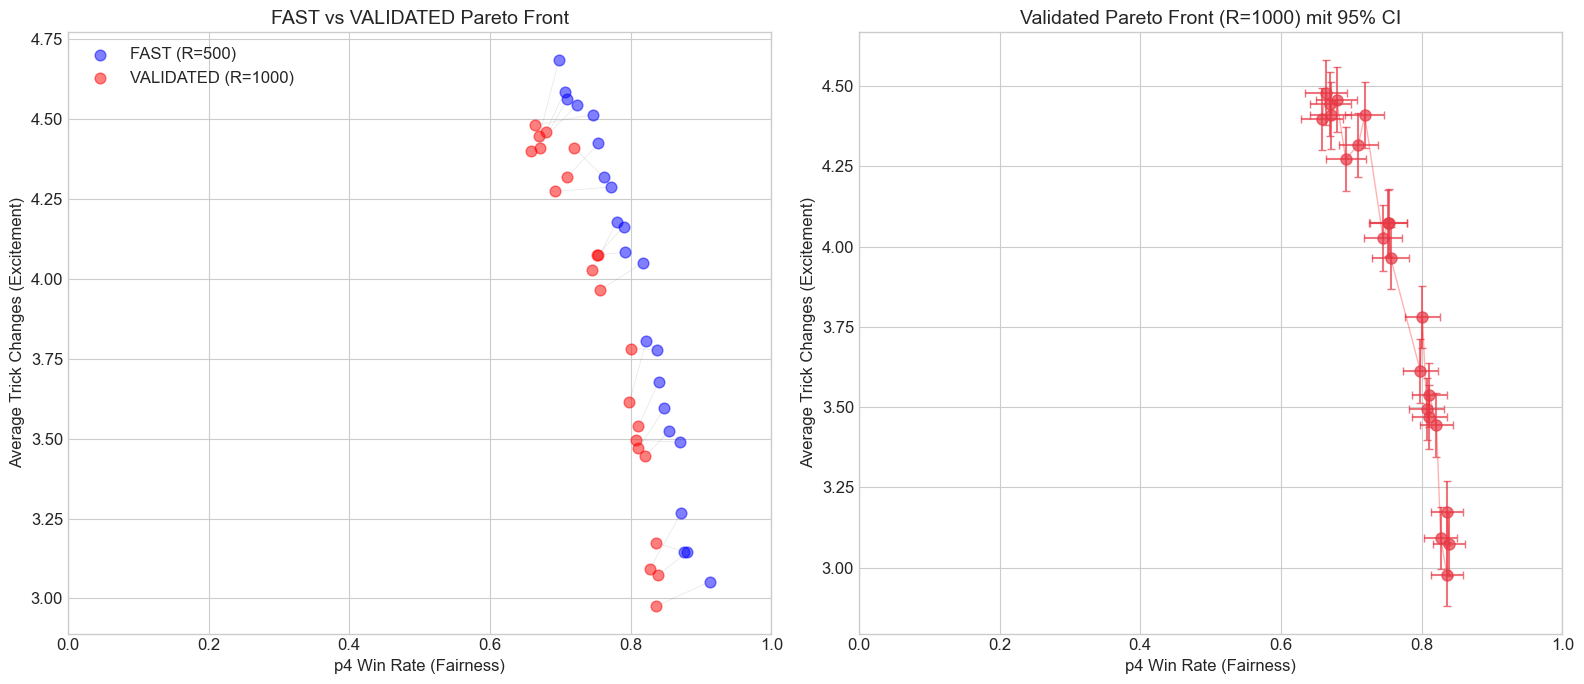


-> Plot gespeichert: plots/pareto_front_validated.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax1 = axes[0]
ax1.scatter(fast_win_rates, fast_trick_changes, c='blue', s=60, alpha=0.5, label=f'FAST (R={R_EVAL_FAST})')
ax1.scatter(validated_df['win_rate'], validated_df['trick_changes'], c='red', s=60, alpha=0.5, label=f'VALIDATED (R={R_EVAL_FINAL})')

for i in range(len(fast_win_rates)):
    ax1.plot([fast_win_rates[i], validated_df['win_rate'].iloc[i]], 
             [fast_trick_changes[i], validated_df['trick_changes'].iloc[i]], 
             'gray', alpha=0.2, linewidth=0.5)

ax1.set_xlabel('p4 Win Rate (Fairness)', fontsize=12)
ax1.set_ylabel('Average Trick Changes (Excitement)', fontsize=12)
ax1.set_title('FAST vs VALIDATED Pareto Front', fontsize=14)
ax1.legend()
ax1.set_xlim(0, 1)

ax2 = axes[1]
sorted_idx = np.argsort(validated_df['win_rate'].values)
ax2.errorbar(
    validated_df['win_rate'].values[sorted_idx],
    validated_df['trick_changes'].values[sorted_idx],
    xerr=validated_df['win_rate_ci'].values[sorted_idx],
    yerr=validated_df['trick_changes_ci'].values[sorted_idx],
    fmt='o',
    capsize=3,
    color='#E63946',
    markersize=8,
    alpha=0.7
)

ax2.plot(validated_df['win_rate'].values[sorted_idx], 
         validated_df['trick_changes'].values[sorted_idx], 
         'r-', alpha=0.3, linewidth=1)

ax2.set_xlabel('p4 Win Rate (Fairness)', fontsize=12)
ax2.set_ylabel('Average Trick Changes (Excitement)', fontsize=12)
ax2.set_title(f'Validated Pareto Front (R={R_EVAL_FINAL}) mit 95% CI', fontsize=14)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pareto_front_validated.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n-> Plot gespeichert: {PLOTS_DIR / 'pareto_front_validated.png'}")

---

## 7. Export der Ergebnisse

In [14]:
np.save(RESULTS_DIR / 'pareto_front_X.npy', fast_front_X)
np.save(RESULTS_DIR / 'pareto_front_F.npy', fast_front_F)

validated_df.to_csv(RESULTS_DIR / 'validated_front.csv', index=False)

optimization_results = {
    "algo_config": ALGO_CONFIG,
    "elapsed_time_seconds": elapsed_time,
    "validation_time_seconds": validation_time,
    "n_solutions": len(fast_front_X),
    "fast_stats": {
        "win_rate_min": float(fast_win_rates.min()),
        "win_rate_max": float(fast_win_rates.max()),
        "trick_changes_min": float(fast_trick_changes.min()),
        "trick_changes_max": float(fast_trick_changes.max())
    },
    "validated_stats": {
        "win_rate_min": float(validated_df['win_rate'].min()),
        "win_rate_max": float(validated_df['win_rate'].max()),
        "trick_changes_min": float(validated_df['trick_changes'].min()),
        "trick_changes_max": float(validated_df['trick_changes'].max())
    }
}

with open(RESULTS_DIR / 'optimization_results.json', 'w') as f:
    json.dump(optimization_results, f, indent=2)

print("Ergebnisse gespeichert:")
print(f"  - {RESULTS_DIR / 'pareto_front_X.npy'}")
print(f"  - {RESULTS_DIR / 'pareto_front_F.npy'}")
print(f"  - {RESULTS_DIR / 'validated_front.csv'}")
print(f"  - {RESULTS_DIR / 'optimization_results.json'}")

Ergebnisse gespeichert:
  - results/pareto_front_X.npy
  - results/pareto_front_F.npy
  - results/validated_front.csv
  - results/optimization_results.json


---

## Zusammenfassung Notebook 2

**Durchgeführt:**
1. NSGA-II Optimierung mit Pop=80, Gen=60
2. Fast Run mit R=100 Simulationen pro Evaluation
3. Validation aller Lösungen mit R=1000

**Ergebnisse:**
- Pareto-Front mit Trade-off zwischen Fairness und Excitement gefunden
- Validated Front zeigt robuste Schätzungen mit Konfidenzintervallen

**Nächster Schritt:** -> `03_analysis.ipynb` für Quality Indicators und Deck-Analyse